# Assingment#3: Transformers+RAG
## Name: Arqam Zulfiqar     Roll#: 23I-2608    Section: C

## Step 1: Data Loading & Subset Creation:

In [2]:
import json
import gzip
import random
from collections import Counter

# Configuration
CATEGORIES = ['electronics', 'beauty', 'home']
SAMPLES_PER_CATEGORY = 15000
MAX_SEQ_LEN = 128  # You can adjust this based on GPU memory

def load_amazon_data(file_path, category_label):
    data = []
    with gzip.open(file_path, 'rt') as f:
        for line in f:
            item = json.loads(line)
            text = item.get('reviewText', '')
            rating = item.get('overall', 0)
            
            if text and rating:
                # Part A Sentiment Mapping: 1-2 Neg (0), 3 Neut (1), 4-5 Pos (2)
                if rating <= 2: sentiment = 0
                elif rating == 3: sentiment = 1
                else: sentiment = 2
                
                data.append({
                    'text': text.lower(),
                    'sentiment': sentiment,
                    'category': category_label
                })
    return random.sample(data, min(len(data), SAMPLES_PER_CATEGORY))

# Load and combine
raw_dataset = []
for i, cat in enumerate(CATEGORIES):
    # Ensure you have these files in your directory
    raw_dataset.extend(load_amazon_data(f'Dataset/{cat}.json.gz', i))

random.shuffle(raw_dataset)

## Step 2: Custom Tokenization & Vocabulary:

In [3]:
class SimpleTokenizer:
    def __init__(self, vocab_size=20000):
        self.vocab_size = vocab_size
        self.word2idx = {"[PAD]": 0, "[UNK]": 1, "[SOS]": 2, "[EOS]": 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        
    def build_vocab(self, sentences):
        word_counts = Counter()
        for s in sentences:
            word_counts.update(s.split())
        
        most_common = word_counts.most_common(self.vocab_size - 4)
        for word, _ in most_common:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, text, max_len):
        tokens = text.split()[:max_len-2]
        token_ids = [self.word2idx["[SOS]"]] + \
                    [self.word2idx.get(t, self.word2idx["[UNK]"]) for t in tokens] + \
                    [self.word2idx["[EOS]"]]
        
        # Padding
        padding_len = max_len - len(token_ids)
        token_ids += [self.word2idx["[PAD]"]] * padding_len
        return token_ids

# Split Data (70/15/15)
train_idx = int(0.7 * len(raw_dataset))
val_idx = int(0.85 * len(raw_dataset))

train_data = raw_dataset[:train_idx]
val_data = raw_dataset[train_idx:val_idx]
test_data = raw_dataset[val_idx:]

# Build vocab ONLY from training data
tokenizer = SimpleTokenizer()
tokenizer.build_vocab([d['text'] for d in train_data])

## Step 3: The Transformer Building Blocks (Part A):

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        
        self.d_k = d_model // num_heads
        
        # Wq, Wk, Wv projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size = x.size(0)
        
        # Linear projections and split into heads
        q = self.W_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Scaled Dot-Product Attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, v) # (batch, heads, seq, d_k)
        
        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(context)

## Step 4: Position-wise Feed-Forward & Encoder Block:

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sublayer 1: Attention + Residual + Norm
        attn_out = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        
        # Sublayer 2: Feed Forward + Residual + Norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

##  Step 5: The Multi-Task Transformer Encoder:

In [6]:
class MultiTaskEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, max_len, d_model))
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        
        # Multi-task heads
        self.sentiment_head = nn.Linear(d_model, 3) # Neg, Neut, Pos
        self.category_head = nn.Linear(d_model, 3)  # Beauty, Electronics, Home
        
    def forward(self, x, mask=None):
        # Add embedding and positional info
        x = self.embedding(x) + self.pos_encoding[:, :x.size(1), :]
        
        for layer in self.layers:
            x = layer(x, mask)
            
        # Global Average Pooling to get the "fixed-dimensional vector representation"
        # This pooled_output is what we will save for Part B retrieval
        pooled_output = torch.mean(x, dim=1)
        
        sentiment_logits = self.sentiment_head(pooled_output)
        category_logits = self.category_head(pooled_output)
        
        return sentiment_logits, category_logits, pooled_output

## Step 6: Training Pipeline & Combined Loss:

In [7]:
# Hyperparameters
D_MODEL = 256
NUM_LAYERS = 4
NUM_HEADS = 8
D_FF = 512
LEARNING_RATE = 1e-4

model = MultiTaskEncoder(len(tokenizer.word2idx), D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, MAX_SEQ_LEN)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

def train_step(batch_tokens, batch_sentiment, batch_category):
    model.train()
    optimizer.zero_grad()
    
    # Generate padding mask (masking out [PAD] tokens so attention ignores them)
    mask = (batch_tokens != 0).unsqueeze(1).unsqueeze(2) # (batch, 1, 1, seq_len)
    
    s_logits, c_logits, _ = model(batch_tokens, mask)
    
    loss_s = criterion(s_logits, batch_sentiment)
    loss_c = criterion(c_logits, batch_category)
    
    total_loss = loss_s + loss_c # Combined Loss
    total_loss.backward()
    optimizer.step()
    
    return total_loss.item()

## Step#7: Training Loop & Metric Tracking:

In [8]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Convert data to Tensors (assuming you have 'tokenizer', 'train_data', etc. from previous steps)
def prepare_tensor_data(data_list):
    tokens = torch.tensor([tokenizer.encode(d['text'], MAX_SEQ_LEN) for d in data_list])
    sentiments = torch.tensor([d['sentiment'] for d in data_list])
    categories = torch.tensor([d['category'] for d in data_list])
    return TensorDataset(tokens, sentiments, categories)

train_loader = DataLoader(prepare_tensor_data(train_data), batch_size=32, shuffle=True)
val_loader = DataLoader(prepare_tensor_data(val_data), batch_size=32)

# History for plotting
history = {'loss': [], 'sent_acc': [], 'cat_acc': []}

epochs = 5 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct_s, correct_c, total = 0, 0, 0
    
    for batch in train_loader:
        b_tokens, b_sent, b_cat = [t.to(device) for t in batch]
        
        optimizer.zero_grad()
        mask = (b_tokens != 0).unsqueeze(1).unsqueeze(2).to(device)
        
        s_logits, c_logits, _ = model(b_tokens, mask)
        
        loss_s = criterion(s_logits, b_sent)
        loss_c = criterion(c_logits, b_cat)
        loss = loss_s + loss_c
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Calculate Accuracy
        correct_s += (s_logits.argmax(1) == b_sent).sum().item()
        correct_c += (c_logits.argmax(1) == b_cat).sum().item()
        total += b_tokens.size(0)
    
    # Save metrics
    history['loss'].append(total_loss / len(train_loader))
    history['sent_acc'].append(correct_s / total)
    history['cat_acc'].append(correct_c / total)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {history['loss'][-1]:.4f} - Sent Acc: {history['sent_acc'][-1]:.4f} - Cat Acc: {history['cat_acc'][-1]:.4f}")

Starting training on cpu...
Epoch 1/5 - Loss: 1.2020 - Sent Acc: 0.8085 - Cat Acc: 0.7110
Epoch 2/5 - Loss: 0.7929 - Sent Acc: 0.8222 - Cat Acc: 0.8851
Epoch 3/5 - Loss: 0.6698 - Sent Acc: 0.8337 - Cat Acc: 0.9171
Epoch 4/5 - Loss: 0.5742 - Sent Acc: 0.8459 - Cat Acc: 0.9416
Epoch 5/5 - Loss: 0.4996 - Sent Acc: 0.8581 - Cat Acc: 0.9569


## Step#8: Generating the Required Curves:

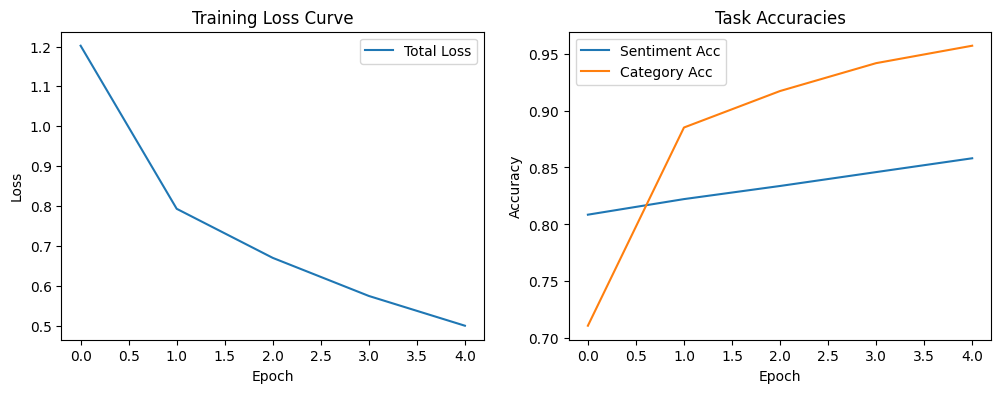

In [9]:
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Total Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracies
plt.subplot(1, 2, 2)
plt.plot(history['sent_acc'], label='Sentiment Acc')
plt.plot(history['cat_acc'], label='Category Acc')
plt.title('Task Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step#9: Saving the Embeddings:

In [10]:
model.eval()
all_embeddings = []
with torch.no_grad():
    # We save embeddings for the TRAINING set for retrieval purposes
    full_train_loader = DataLoader(prepare_tensor_data(train_data), batch_size=32)
    for batch in full_train_loader:
        tokens = batch[0].to(device)
        mask = (tokens != 0).unsqueeze(1).unsqueeze(2)
        _, _, embeddings = model(tokens, mask)
        all_embeddings.append(embeddings.cpu())

# Concatenate and save
train_embeddings = torch.cat(all_embeddings, dim=0)
torch.save(train_embeddings, 'train_embeddings.pt')
print("Embeddings saved for Part B!")

Embeddings saved for Part B!
